# River Flow Anomaly Detection and Correction

Method 1: FD + Reversal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation

## Load Data

In [2]:
import pandas as pd

file_path = "river_data.xlsx"

df = pd.read_excel(
    file_path,
    header=2
)

# Remove catchment area row
df = df.iloc[1:].reset_index(drop=True)

# Keep only first four columns
df = df.iloc[:, :4]

df.columns = [
    'datetime',
    'tributary_A',
    'tributary_B',
    'combined_river'
]

df['datetime'] = pd.to_datetime(df['datetime'])

df['tributary_A'] = pd.to_numeric(df['tributary_A'])
df['tributary_B'] = pd.to_numeric(df['tributary_B'])
df['combined_river'] = pd.to_numeric(df['combined_river'])

df.head()

,datetime,tributary_A,tributary_B,combined_river
0,2002-05-01 01:00:00,755.3,867.262870,2787.55
1,2002-05-01 02:00:00,755.3,867.262870,2691.52
2,2002-05-01 03:00:00,784.5,809.916908,2596.59
3,2002-05-01 04:00:00,784.5,809.916908,2491.12
4,2002-05-01 05:00:00,784.5,701.249553,2421.59


## Initial Visualization

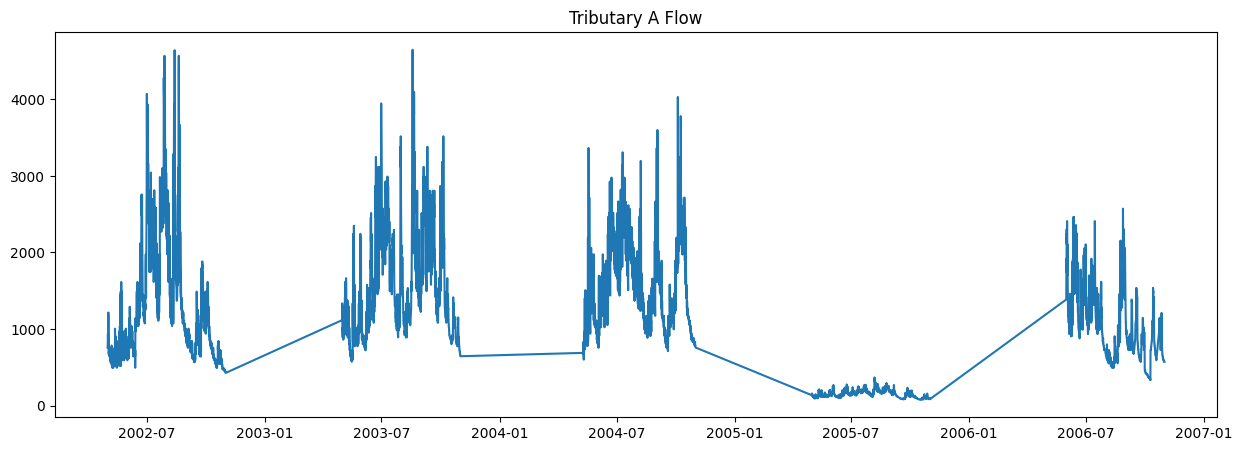

In [3]:
plt.figure(figsize=(15,5))
plt.plot(df['datetime'], df['tributary_A'])
plt.title('Tributary A Flow')
plt.show()

## First Diffirence + Reversal

In [4]:
def detect_reversal_anomalies(series, threshold_factor=4):

    diff = series.diff()

    threshold = threshold_factor * diff.std()

    anomalies = []

    for i in range(1, len(series)-1):

        jump1 = diff.iloc[i]
        jump2 = diff.iloc[i+1]

        if (
            abs(jump1) > threshold
            and abs(jump2) > threshold
            and np.sign(jump1) != np.sign(jump2)
        ):
            anomalies.append(i)

    return anomalies

## Detect Anomalies

In [5]:
anomalies_A = detect_reversal_anomalies(
    df['tributary_A']
)

anomalies_B = detect_reversal_anomalies(
    df['tributary_B']
)

print("A anomalies:", len(anomalies_A))
print("B anomalies:", len(anomalies_B))

A anomalies: 12
B anomalies: 54


## Visualize Detected Anomalies

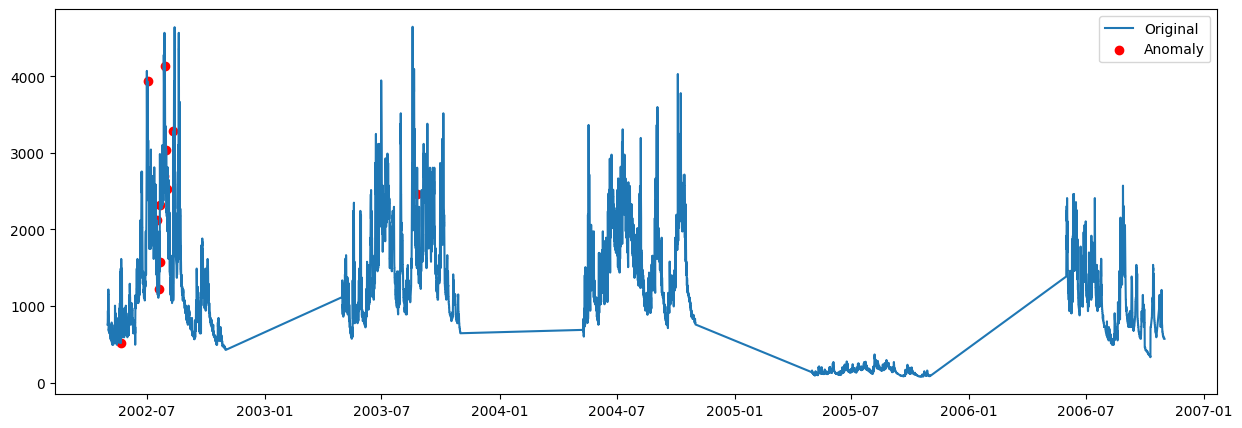

In [6]:
plt.figure(figsize=(15,5))

plt.plot(
    df['datetime'],
    df['tributary_A'],
    label='Original'
)

plt.scatter(
    df.loc[anomalies_A, 'datetime'],
    df.loc[anomalies_A, 'tributary_A'],
    color='red',
    label='Anomaly'
)

plt.legend()
plt.show()

## Replace Anomalies with NaN

In [7]:
df_clean = df.copy()

df_clean.loc[anomalies_A, 'tributary_A'] = np.nan
df_clean.loc[anomalies_B, 'tributary_B'] = np.nan

## Interpolate Missing Values

In [8]:
df_clean['tributary_A'] = (
    df_clean['tributary_A']
    .interpolate(method='linear')
)

df_clean['tributary_B'] = (
    df_clean['tributary_B']
    .interpolate(method='linear')
)

## Compare Before and After

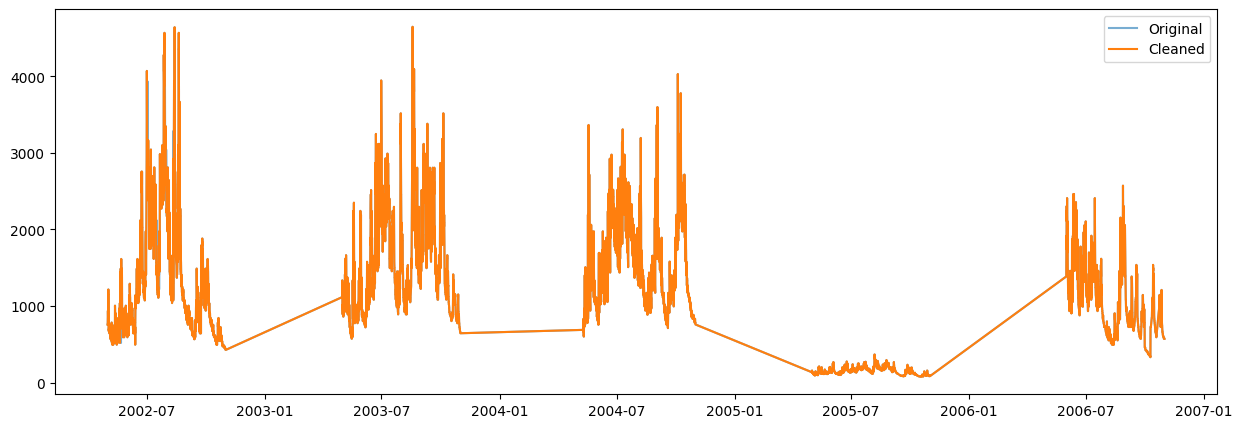

In [9]:
plt.figure(figsize=(15,5))

plt.plot(
    df['datetime'],
    df['tributary_A'],
    label='Original',
    alpha=0.6
)

plt.plot(
    df_clean['datetime'],
    df_clean['tributary_A'],
    label='Cleaned'
)

plt.legend()
plt.show()

## Clean Combined River

In [10]:
anomalies_C = detect_reversal_anomalies(
    df['combined_river']
)

df_clean.loc[
    anomalies_C,
    'combined_river'
] = np.nan

df_clean['combined_river'] = (
    df_clean['combined_river']
    .interpolate()
)

## Save Cleaned Dataset

In [11]:
df_clean.rename(columns={
    'tributary_A': 'Tamen',
    'tributary_B': 'Daporizo',
    'combined_river': 'Gerukamukh'
}, inplace=True)

df_clean.to_excel(
    'cleaned_reversal.xlsx',
    index=False
)

print('Saved: cleaned_reversal.xlsx')

print("Tributary A:", len(anomalies_A))

print("Tributary B:", len(anomalies_B))

print("Combined River:", len(anomalies_C))



for idx in anomalies_A[:5]:

    print("\nAnomaly at index:", idx)

    print(df.iloc[idx-3:idx+4])

Saved: cleaned_reversal.xlsx
Tributary A: 12
Tributary B: 54
Combined River: 20

Anomaly at index: 497
               datetime  tributary_A  tributary_B  combined_river
494 2002-05-21 15:00:00      1179.66  1150.277218         2982.83
495 2002-05-21 16:00:00      1143.55  1218.734595         2921.35
496 2002-05-21 17:00:00      1143.55  1236.166069         2896.87
497 2002-05-21 18:00:00       518.15  1253.724486         2848.11
498 2002-05-21 19:00:00      1108.03  1289.222334         2848.11
499 2002-05-21 20:00:00      1073.08  1361.743335         2982.83
500 2002-05-21 21:00:00      1073.08  1398.767196         2958.19

Anomaly at index: 1282
                datetime  tributary_A  tributary_B  combined_river
1279 2002-07-01 23:00:00      2927.26  2541.113809         5720.09
1280 2002-07-02 00:00:00      3044.81  2541.113809         5720.09
1281 2002-07-02 01:00:00      3164.75  2800.723459         6011.78
1282 2002-07-02 02:00:00      3934.77  2908.194578         6089.32
1283 2002-